In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("rock_density_xray.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rebound Signal Strength nHz  300 non-null    float64
 1   Rock Density kg/m3           300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


In [4]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [5]:
df.columns=['Signal',"Density"]

<Axes: xlabel='Signal', ylabel='Density'>

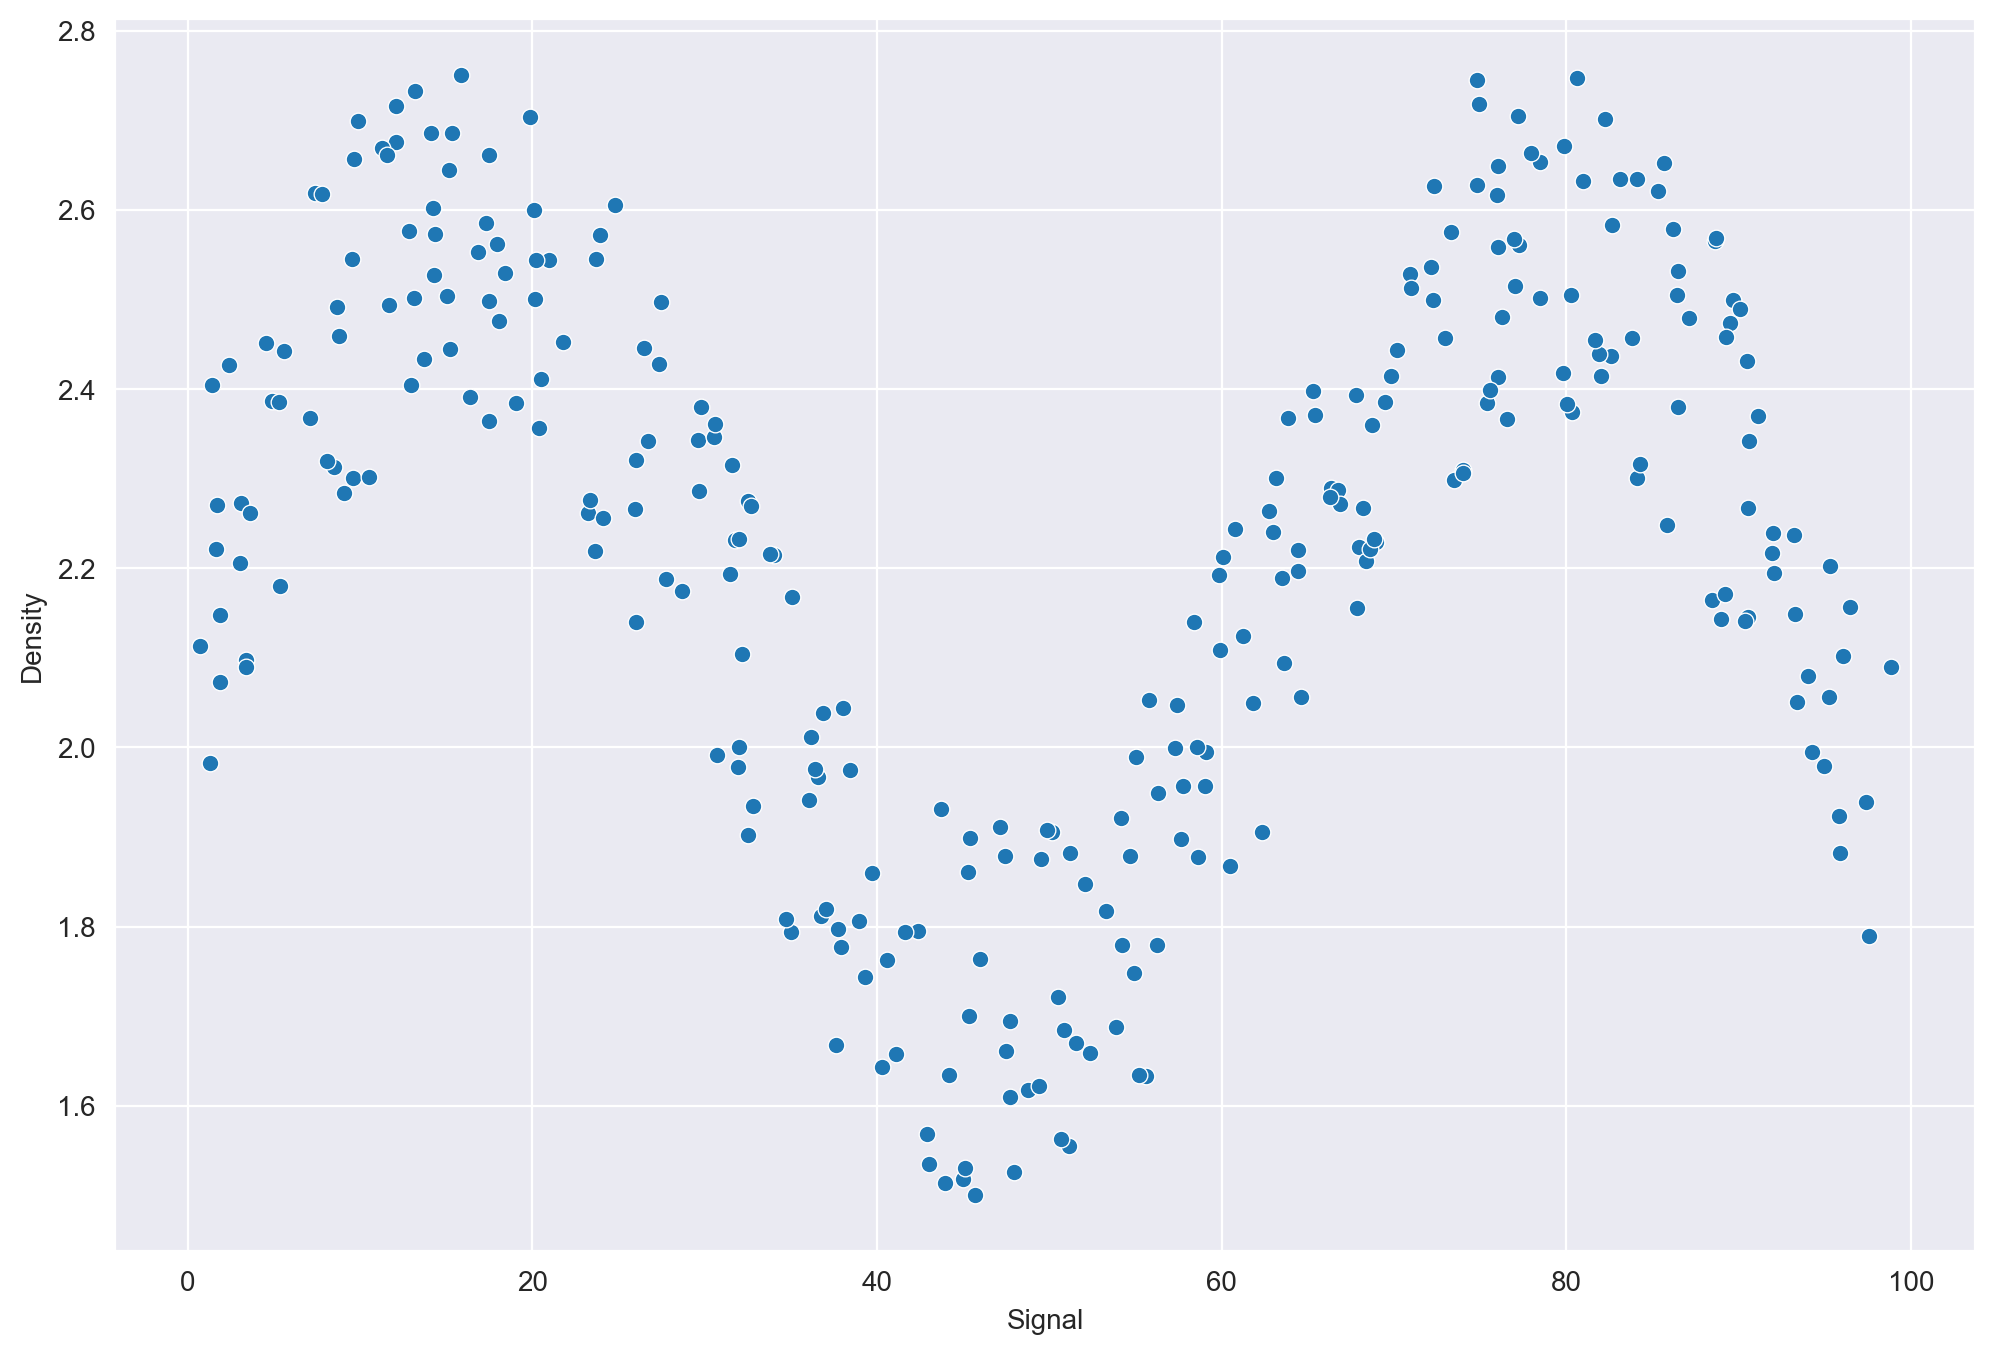

In [6]:
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Signal',y='Density',data=df)

In [7]:
X = df['Signal'].values.reshape(-1, 1)
y = df['Density']

In [8]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=101)

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lr_model = LinearRegression()

In [15]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.22
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[461.18]


In [16]:
lr_preds = lr_model.predict(X_test)

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [19]:
mean_absolute_error(y_test, lr_preds)

0.211198973318633

In [20]:
np.sqrt(mean_squared_error(y_test, lr_preds))

np.float64(0.2570051996584629)

In [21]:
0.25 / (2.7 - 0.5 )

0.11363636363636363

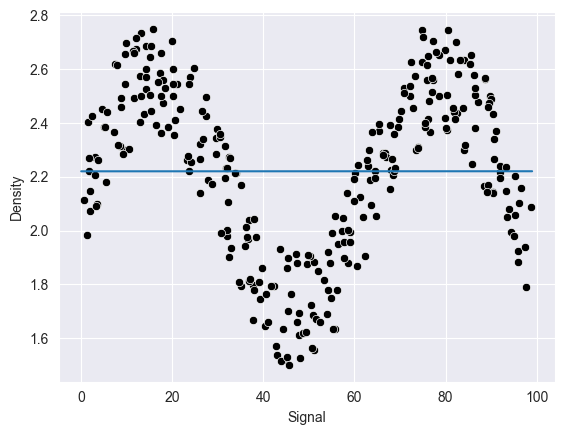

In [34]:
signal_range = np.arange(0, 100)
lr_output = lr_model.predict(signal_range.reshape(-1, 1))

sns.scatterplot(x='Signal', y='Density', data=df, color='black')
plt.plot(signal_range, lr_output)

In [35]:
model = LinearRegression()

In [36]:
def run_model(model, X_train, y_train, X_test, y_test):
    #Fit Model
    model.fit(X_train, y_train)
    # Get Metrics
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"RMSE: {rmse}")
    # Plot result
    signal_range = np.arange(0, 100)
    output = model.predict(signal_range.reshape(-1, 1))
    plt.figure(figsize = (8, 5), dpi = 100)
    sns.scatterplot(x = 'Signal', y = 'Density', data = df, color = 'black')
    plt.plot(signal_range, output)

RMSE: 0.2570051996584629


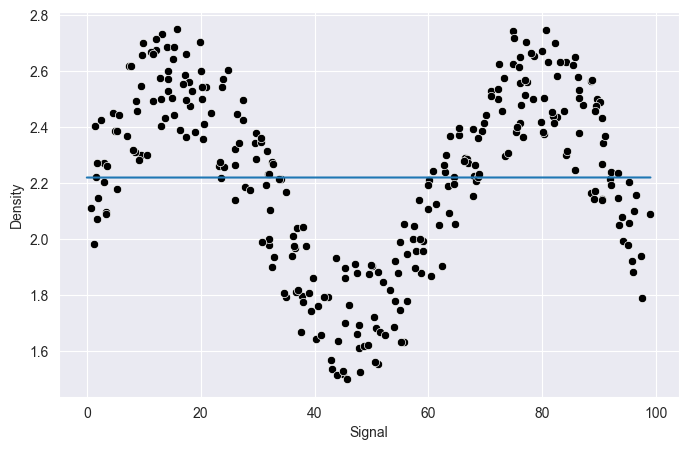

In [37]:
run_model(model, X_train, y_train, X_test, y_test)

RMSE: 0.2817309563725596


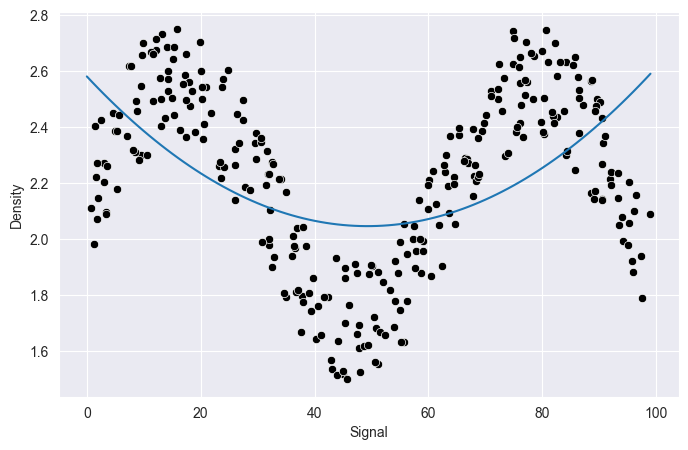

In [38]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

pipe = make_pipeline(PolynomialFeatures(2), LinearRegression())
run_model(pipe, X_train, y_train, X_test, y_test)

RMSE: 0.2491676569664078


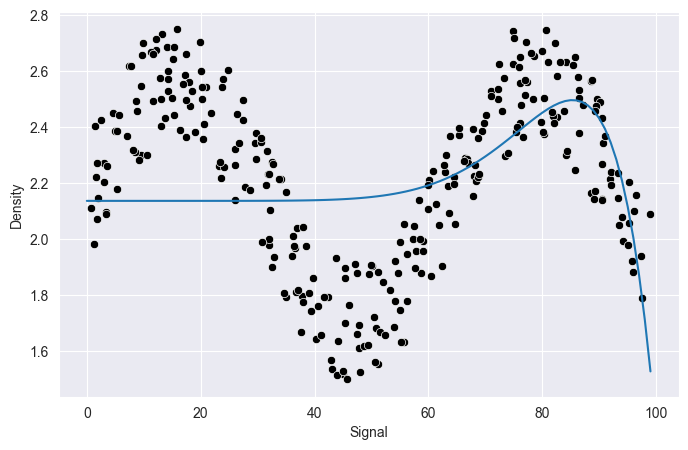

In [39]:
pipe = make_pipeline(PolynomialFeatures(10), LinearRegression())
run_model(pipe, X_train, y_train, X_test, y_test)

RMSE: 0.1523487028635337
RMSE: 0.13730685016923647
RMSE: 0.13277855732740926


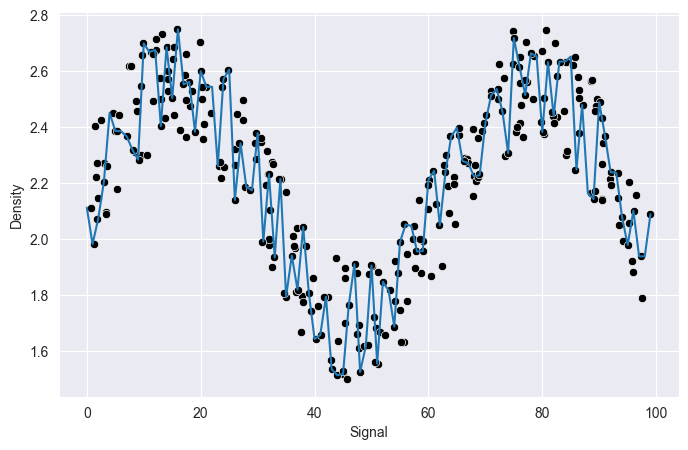

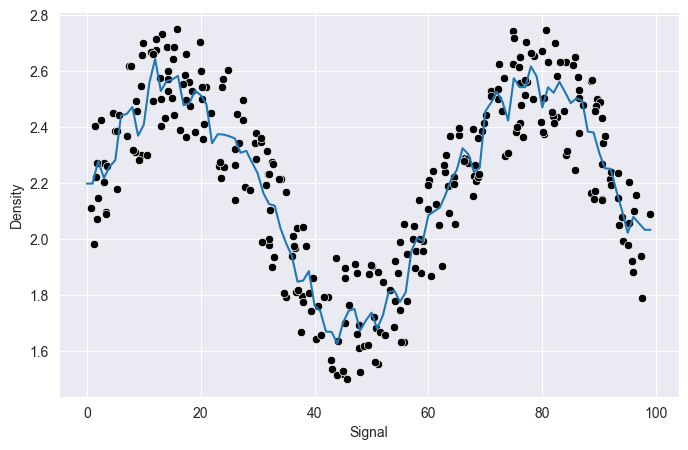

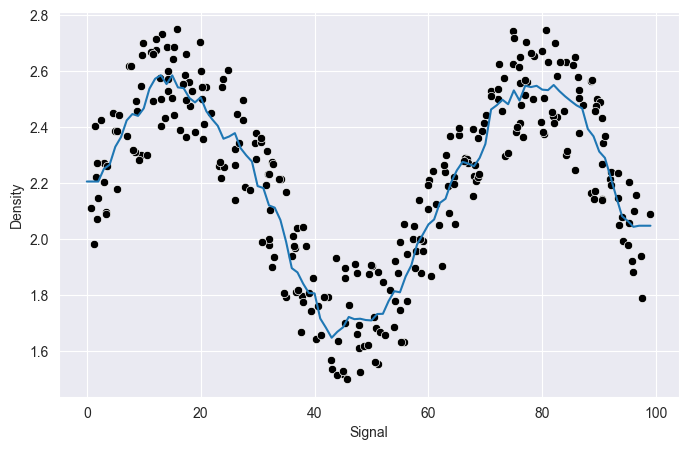

In [40]:
from sklearn.neighbors import KNeighborsRegressor

preds = {}
k_values = [1, 5, 10]

for n in k_values:
    model = KNeighborsRegressor(n_neighbors=n)
    run_model(model, X_train, y_train, X_test, y_test)

RMSE: 0.1523487028635337


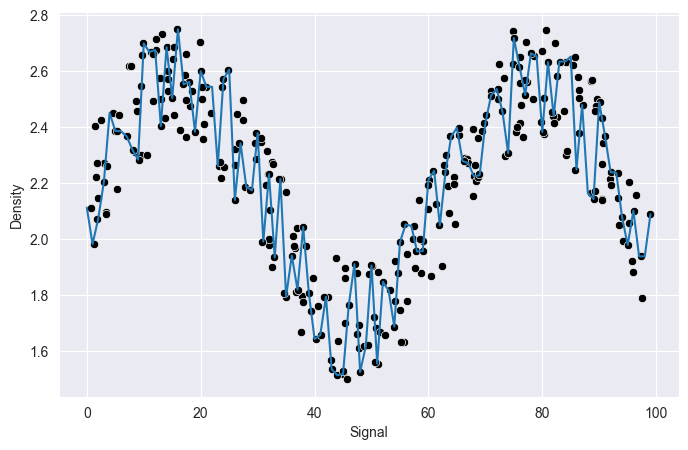

In [41]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor()
run_model(tree, X_train, y_train, X_test, y_test)

In [42]:
tree.get_n_leaves()

np.int64(270)

RMSE: 0.12646999302046696


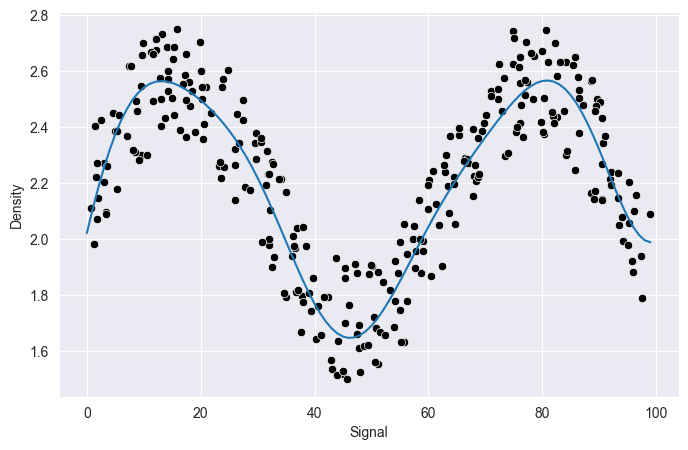

In [43]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 5, 10, 100, 1000],
    'gamma': ['auto', 'scale']
}

svr = SVR()
grid = GridSearchCV(svr, param_grid)
run_model(grid, X_train, y_train, X_test, y_test)

RMSE: 0.14217321344969094
RMSE: 0.13610117210153136
RMSE: 0.13211018439892436
RMSE: 0.13271942629295438


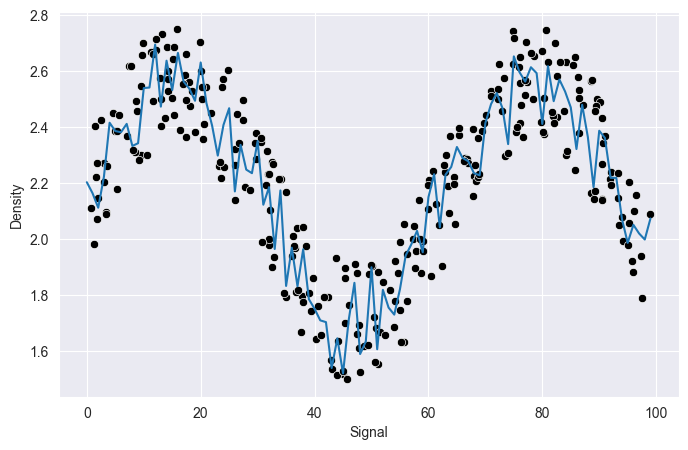

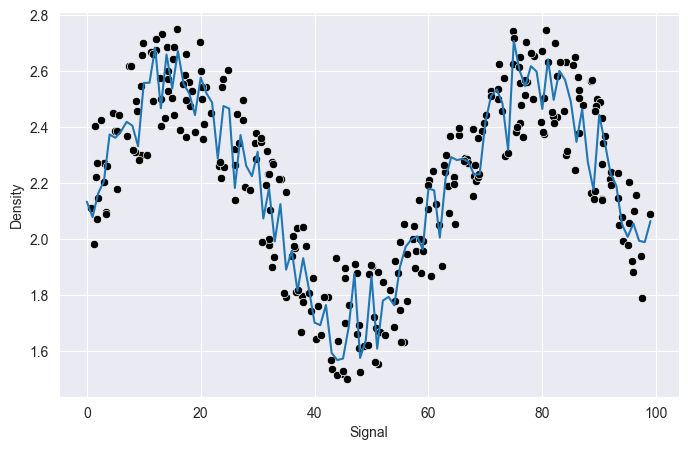

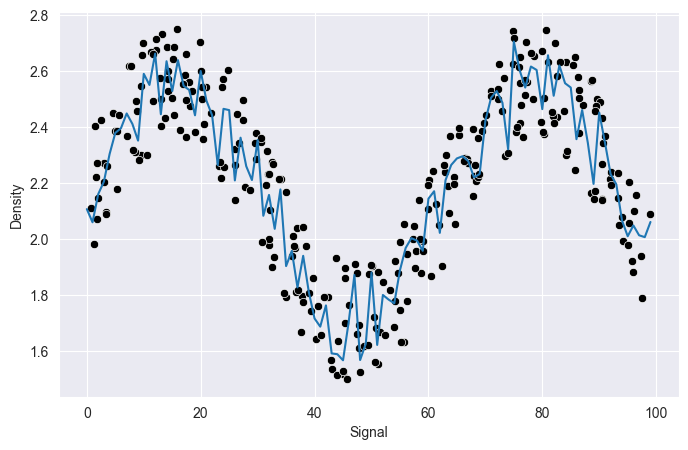

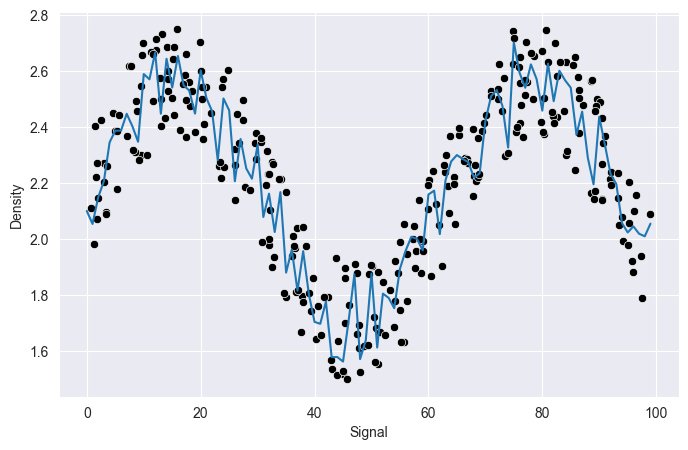

In [44]:
from sklearn.ensemble import RandomForestRegressor

trees = [10, 50, 100, 150]
for n in trees:
    RF = RandomForestRegressor(n_estimators=n)
    run_model(RF, X_train, y_train, X_test, y_test)

RMSE: 0.13294148649584667


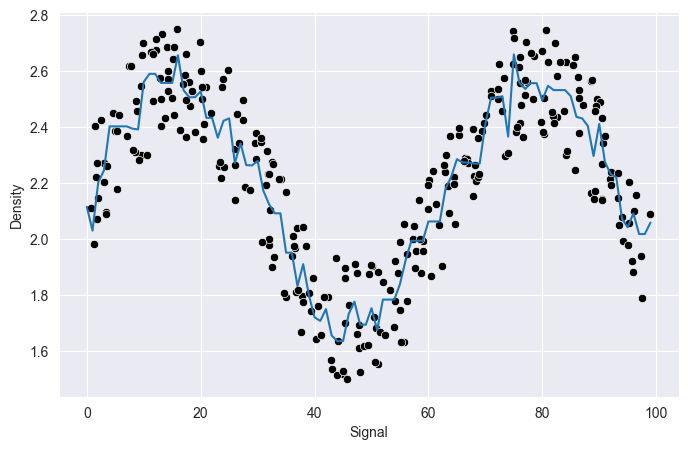

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

GBR = GradientBoostingRegressor()
run_model(GBR, X_train, y_train, X_test, y_test)

RMSE: 0.14142012651116145


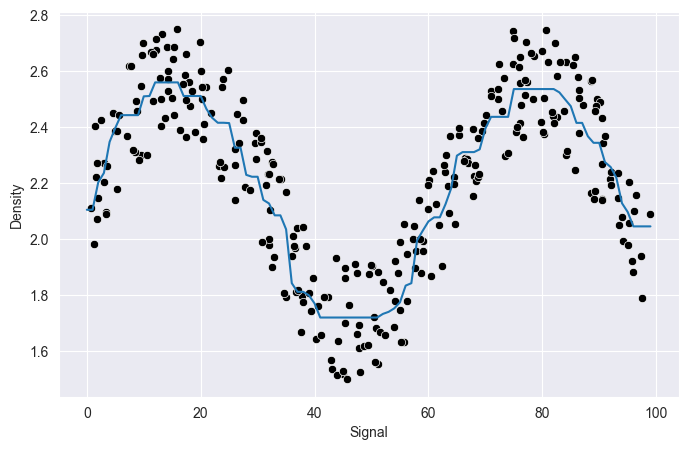

In [46]:
from sklearn.ensemble import AdaBoostRegressor

ABR = AdaBoostRegressor()
run_model(ABR, X_train, y_train, X_test, y_test)